---
# Mode B: Custom Control

Run cells in this order:
1. **Configuration Cell** - Set experiment, model, and display names
2. **Data Loading Cell** - Initialize visualizer with your settings
3. **Chart Cells (3-8)** - Generate individual charts using configured parameters

## Quick Start Examples:

### Example 1: Visualize Exp2 with GPT-5 Chat
```python
SELECTED_EXPERIMENT = 'exp2'
SELECTED_MODEL = "openai/gpt-5-chat-latest"
```

### Example 2: Compare baseline experiments for Gemini
```python
SELECTED_EXPERIMENT = 'exp1'
EXPERIMENTS_TO_COMPARE = ['exp1', 'exp2']
SELECTED_MODEL = "gemini/gemini-2.5-flash"
```

### Example 3: Custom model names for publication
```python
CUSTOM_MODEL_NAMES = {
    'openai/gpt-5-chat-latest': 'GPT-5',
    'gemini/gemini-2.5-flash': 'Gemini Flash',
}
```

In [1]:
# ============================================================================
# Configuration - Customize Your Visualization Settings
# ============================================================================

# --- Experiment Selection ---
# Choose which experiment(s) to visualize
SELECTED_EXPERIMENT = 'exp1'  # Options: 'exp1', 'exp2', 'exp3'
EXPERIMENTS_TO_COMPARE = ['exp1', 'exp2']  # For comparison charts

# --- Model Selection ---
# Choose which model to focus on (or None for all models)
SELECTED_MODEL = "openai/gpt-5.1_medium"  # Set to None to include all models

# --- Custom Display Names ---
# Override default model and experiment names for professional charts
CUSTOM_MODEL_NAMES = {
    'openai/gpt-5': 'GPT-5 (Medium)',
    'openai/gpt-5_medium': 'GPT-5 (Medium)',
    'openai/gpt-5.1_medium': 'GPT-5.1 (Medium)',
    'openai/gpt-5.1_none': 'GPT-5.1 (None)',
    'anthropic/claude-sonnet-4-5': 'Claude Sonnet 4.5',
    'gemini/gemini-2.5-flash': 'Gemini 2.5 Flash',
    'gemini/gemini-2.5-pro': 'Gemini 2.5 Pro',
    'fireworks/accounts_fireworks_models_qwen3-vl-235b-a22b-instruct': 'Qwen3-VL 235B A22B Instruct',
}

CUSTOM_EXP_NAMES = {
    'exp1': 'Exp1 (Original Prompts)',
    'exp2': 'Exp2 (Optimized Prompts)',
    'exp3': 'Exp3 (Until-Correct, Expected)',
}

# --- Chart Settings ---
FIGURE_SIZE_HEATMAP = (14, 10)
FIGURE_SIZE_BARS = (14, 7)
FIGURE_SIZE_SCATTER = (10, 8)
FIGURE_SIZE_BOX = (14, 7)
FIGURE_SIZE_EXP3 = (20, 12)
FIGURE_SIZE_FRONTIER = (10, 10)
FIGURE_SIZE_TIME_PERF = (10, 10)
FIGURE_SIZE_SLOPE = (16, 8)
FIGURE_SIZE_RADAR = (8, 8)

print("=" * 80)
print("Configuration Loaded")
print("=" * 80)
print(f"Selected Experiment: {SELECTED_EXPERIMENT}")
print(f"Experiments to Compare: {EXPERIMENTS_TO_COMPARE}")
print(f"Selected Model: {SELECTED_MODEL if SELECTED_MODEL else 'All models'}")
print(f"Custom Model Names: {len(CUSTOM_MODEL_NAMES)} mappings")
print(f"Custom Experiment Names: {len(CUSTOM_EXP_NAMES)} mappings")
print("\n[READY] Configuration set! Run the next cell to load data.")

Configuration Loaded
Selected Experiment: exp1
Experiments to Compare: ['exp1', 'exp2']
Selected Model: openai/gpt-5.1_medium
Custom Model Names: 8 mappings
Custom Experiment Names: 3 mappings

[READY] Configuration set! Run the next cell to load data.


In [2]:
# ============================================================================
# Mode B: Step 2 - Import Libraries and Load Data
# ============================================================================

from visualize_results import CAPTCHAVisualizer
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 80)
print("Mode B: Custom Chart Control")
print("=" * 80)

# Initialize visualizer with custom display names
viz = CAPTCHAVisualizer(
    results_dir="./results",
    model_names=CUSTOM_MODEL_NAMES,
    exp_names=CUSTOM_EXP_NAMES
)

# View loaded data summary
print("\nData Summary:")
print(f"- Total records: {len(viz.data)}")
print(f"- Task types: {len(viz.task_types)}")
if not viz.data.empty:
    print(f"- Experiments: {sorted(viz.data['experiment'].unique())}")
    print(f"- Models: {sorted(viz.data['provider_model'].unique())}")
else:
    print("[WARNING] No data found")

print("\n[READY] You can now run Cells 3-8 to generate specific charts")

Mode B: Custom Chart Control
Scanning experiment result directories...
[LOADED] exp1/gemini/gemini-2.5-pro (18 records)
[LOADED] exp1/gemini/gemini-2.5-flash (18 records)
[LOADED] exp1/fireworks/accounts_fireworks_models_qwen3-vl-235b-a22b-instruct (18 records)
[LOADED] exp1/anthropic/claude-sonnet-4-5 (18 records)
[LOADED] exp1/openai/gpt-5.1_none (18 records)
[LOADED] exp1/openai/gpt-5.1_medium (18 records)
[LOADED] exp1/openai/gpt-5 (18 records)
[LOADED] exp3/gemini/gemini-2.5-pro (18 task types, converted from Exp3 format)
[LOADED] exp3/gemini/gemini-2.5-flash (18 task types, converted from Exp3 format)
[LOADED] exp3/fireworks/accounts_fireworks_models_qwen3-vl-235b-a22b-instruct (18 task types, converted from Exp3 format)
[LOADED] exp3/anthropic/claude-sonnet-4-5 (18 task types, converted from Exp3 format)
[LOADED] exp3/openai/gpt-5.1_none (18 task types, converted from Exp3 format)
[LOADED] exp3/openai/gpt-5.1_medium (18 task types, converted from Exp3 format)
[LOADED] exp3/opena

## Chart 1: Heatmap - Task Difficulty Overview
Displays all task types' performance across different models.

Generating heatmap exp2...
[SAVED] Heatmap saved: ./figures/heatmap_exp2.pdf


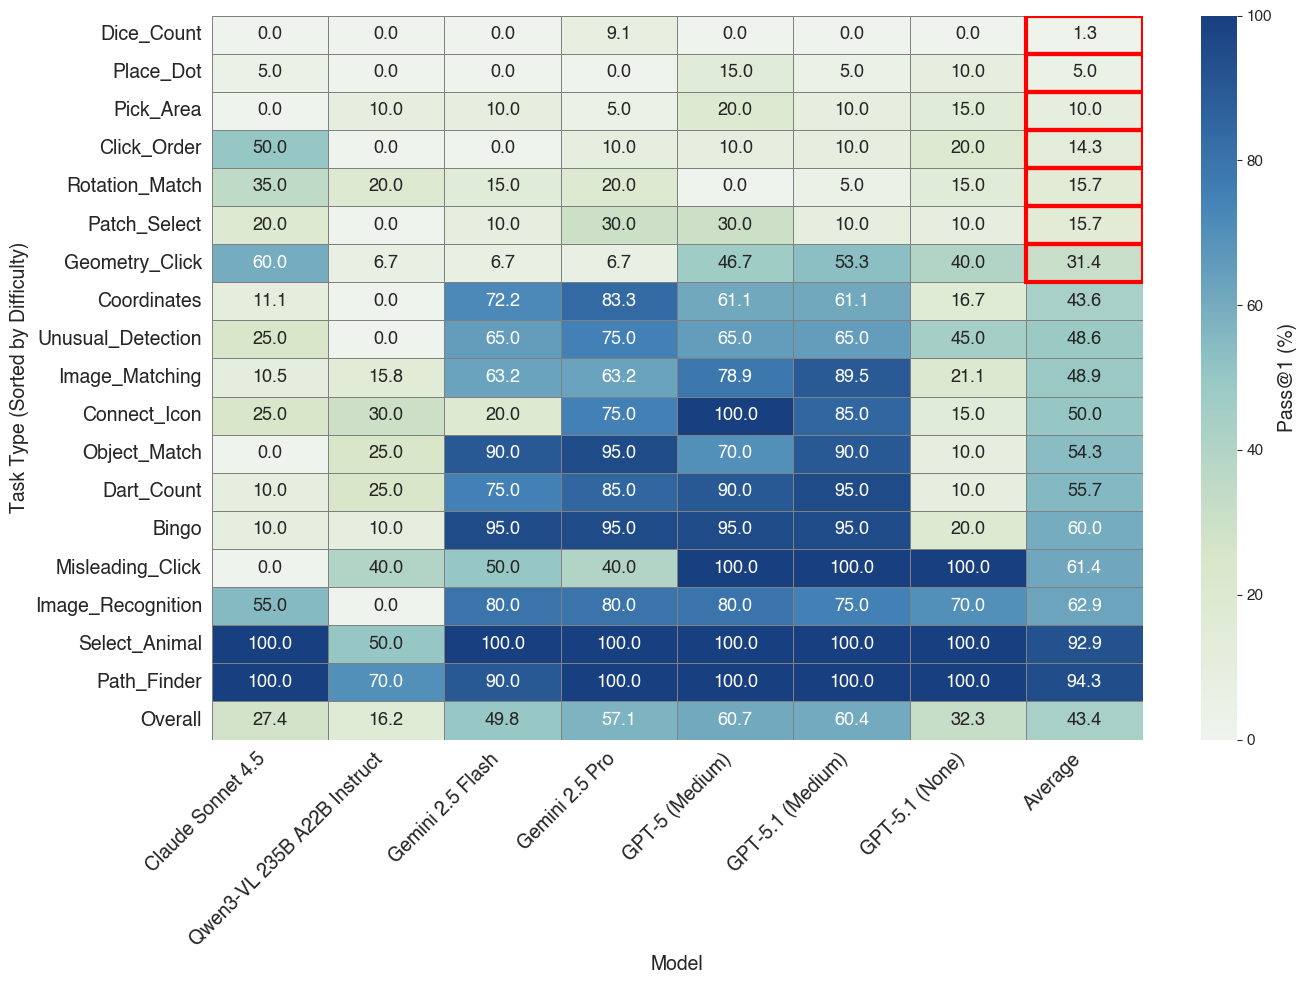

In [9]:
FIGURE_SIZE_HEATMAP = (14, 10)


# Chart 1: Heatmap - Task Difficulty Overview
CHART1_SIZES = {
    'base': 12,         # 全局基准字号
    'title': 14,        # 标题字号
    'label': 14,        # 轴标签字号
    'tick': 14,         # 坐标刻度字号
    'legend': 11,       # 图例字号 / 色条刻度字号
    'annotation': 13,   # 热力图内数字字号
}
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica'],
    'font.size': CHART1_SIZES['base'],
    'axes.titlesize': CHART1_SIZES['title'],
    'axes.labelsize': CHART1_SIZES['label'],
    'xtick.labelsize': CHART1_SIZES['tick'],
    'ytick.labelsize': CHART1_SIZES['tick'],
    'legend.fontsize': CHART1_SIZES['legend'],
})

SELECTED_EXPERIMENT = 'exp2'  # Options: 'exp1', 'exp2', 'exp3', 'exp4'

if not viz.data.empty and SELECTED_EXPERIMENT in viz.data['experiment'].values:
    print(f"Generating heatmap {SELECTED_EXPERIMENT}...")
    fig = viz.plot_heatmap(
        experiment=SELECTED_EXPERIMENT,
        figsize=FIGURE_SIZE_HEATMAP,
        save_path=f"./figures/heatmap_{SELECTED_EXPERIMENT}.pdf"
    )
    if fig:
        ax = fig.axes[0]
        # ax.title.set_fontsize(CHART1_SIZES['title'])
        ax.xaxis.label.set_fontsize(CHART1_SIZES['label'])
        ax.yaxis.label.set_fontsize(CHART1_SIZES['label'])
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontsize(CHART1_SIZES['tick'])
        for txt in ax.texts:
            txt.set_fontsize(CHART1_SIZES['annotation'])
        if len(fig.axes) > 1:
            cbar_ax = fig.axes[1]
            cbar_ax.tick_params(labelsize=CHART1_SIZES['legend'])
    plt.show()
else:
    print(f"[WARNING] {SELECTED_EXPERIMENT} data not available, skipping heatmap")


## Chart 2: Grouped Bar Chart - Optimization Effect Comparison
Compares Pass@1 changes across different experiments.

Generating optimization comparison bar chart for ['exp1', 'exp2']...
[SAVED] Bar chart saved: ./figures/comparison_bars_openai_gpt-5.pdf


AttributeError: 'Legend' object has no attribute 'set_fontsize'

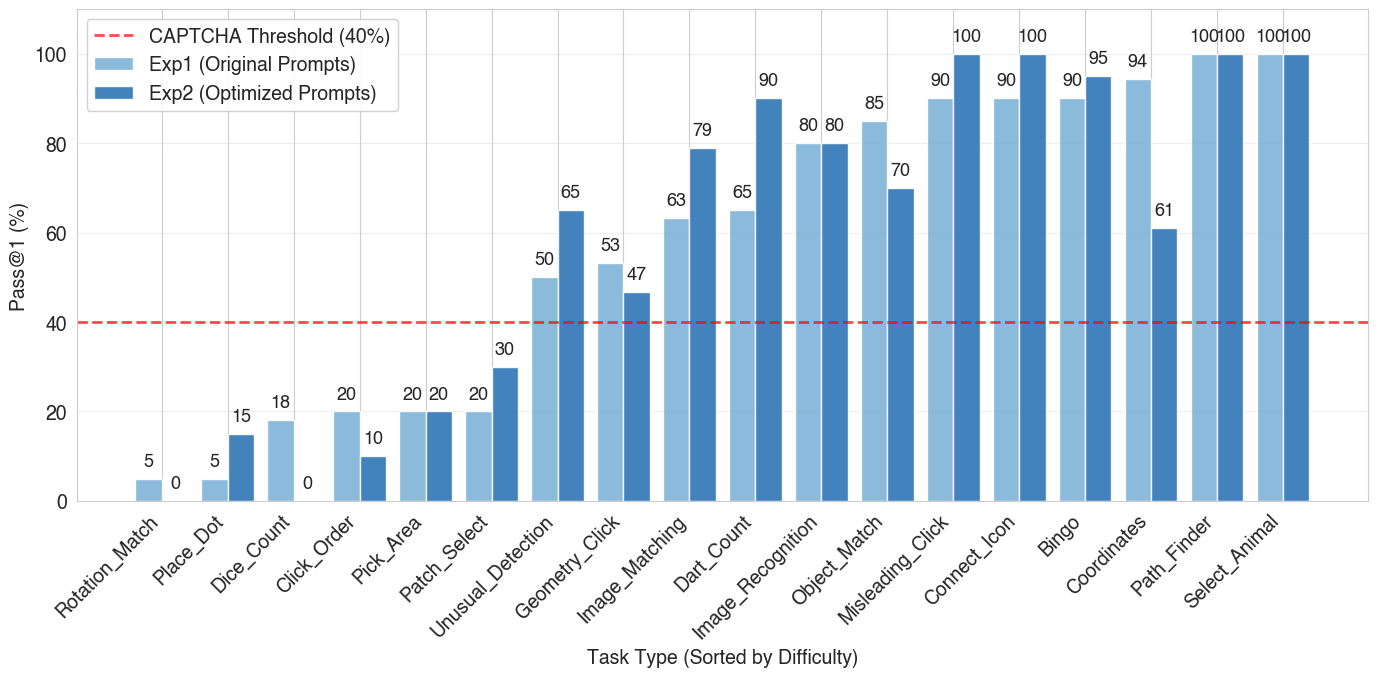

In [10]:
FIGURE_SIZE_BARS = (14, 7)

import re as _re

def _model_slug(name):
    if not name:
        return 'all_models'
    return _re.sub(r'[^A-Za-z0-9._-]+', '_', str(name))


# Chart 2: Grouped Bar Chart - Optimization Effect Comparison
CHART2_SIZES = {
    'base': 14,
    'title': 14,
    'label': 14,
    'tick': 14,
    'legend': 14,
    'bar_label': 13,   # 柱子上方数值字号
}
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica'],
    'font.size': CHART2_SIZES['base'],
    'axes.titlesize': CHART2_SIZES['title'],
    'axes.labelsize': CHART2_SIZES['label'],
    'xtick.labelsize': CHART2_SIZES['tick'],
    'ytick.labelsize': CHART2_SIZES['tick'],
    'legend.fontsize': CHART2_SIZES['legend'],
})

SELECTED_MODEL = "openai/gpt-5"  # Set to None to include all models
EXPERIMENTS_TO_COMPARE = ['exp1', 'exp2']  # For comparison charts

if not viz.data.empty:
    available_exps = [exp for exp in EXPERIMENTS_TO_COMPARE if exp in viz.data['experiment'].values]
    if len(available_exps) >= 2:
        print(f"Generating optimization comparison bar chart for {available_exps}...")
        fig = viz.plot_comparison_bars(
            experiments=available_exps,
            model_filter=SELECTED_MODEL,
            figsize=FIGURE_SIZE_BARS,
            save_path=f"./figures/comparison_bars_{_model_slug(SELECTED_MODEL)}.pdf"
        )
        if fig:
            ax = plt.gca()
            # ax.title.set_fontsize(CHART2_SIZES['title'])
            ax.xaxis.label.set_fontsize(CHART2_SIZES['label'])
            ax.yaxis.label.set_fontsize(CHART2_SIZES['label'])
            for tick in ax.get_xticklabels() + ax.get_yticklabels():
                tick.set_fontsize(CHART2_SIZES['tick'])
            # 柱子数值字号
            for txt in ax.texts:
                txt.set_fontsize(CHART2_SIZES['bar_label'])
            leg = ax.get_legend()
            if leg:
                leg.set_fontsize(CHART2_SIZES['legend'])
        plt.show()
    else:
        print(f"[WARNING] Need at least 2 experiments from {EXPERIMENTS_TO_COMPARE}, found {available_exps}")
else:
    print("[WARNING] No data")


## Chart 3: Scatter Plot - Optimization Resistance Analysis
Identifies which task types remain difficult even after optimization.

Generating optimization resistance scatter plot...
[SAVED] Scatter plot saved: ./figures/optimization_resistance_openai_gpt-5.pdf


AttributeError: 'Legend' object has no attribute 'set_fontsize'

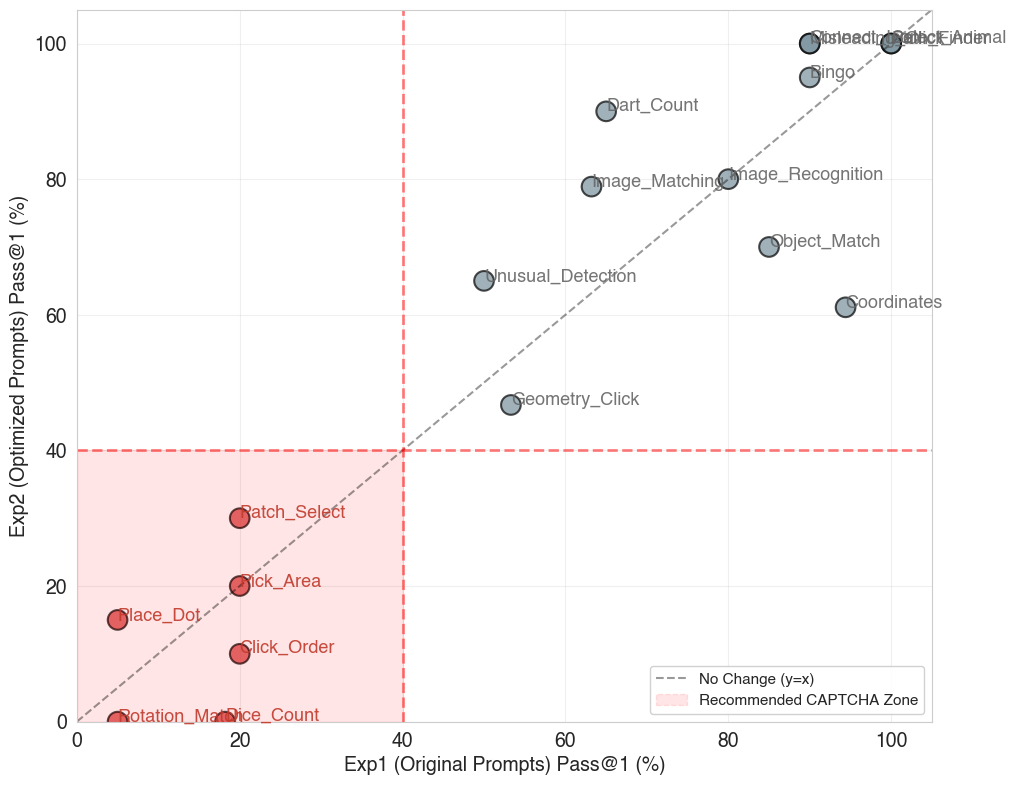

In [3]:
FIGURE_SIZE_SCATTER = (10, 8)


import re as _re

def _model_slug(name):
    if not name:
        return 'all_models'
    return _re.sub(r'[^A-Za-z0-9._-]+', '_', str(name))


# Chart 3: Scatter Plot - Optimization Resistance Analysis
CHART3_SIZES = {
    'base': 12,
    'title': 14,
    'label': 14,
    'tick': 14,
    'legend': 12,
    'annotation': 13,  # 点旁文字
}
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica'],
    'font.size': CHART3_SIZES['base'],
    'axes.titlesize': CHART3_SIZES['title'],
    'axes.labelsize': CHART3_SIZES['label'],
    'xtick.labelsize': CHART3_SIZES['tick'],
    'ytick.labelsize': CHART3_SIZES['tick'],
    'legend.fontsize': CHART3_SIZES['legend'],
})

SELECTED_MODEL = "openai/gpt-5"  # Set to None to include all models
if not viz.data.empty and 'exp1' in viz.data['experiment'].values and 'exp2' in viz.data['experiment'].values:
    print("Generating optimization resistance scatter plot...")
    fig = viz.plot_optimization_resistance(
        base_exp='exp1',
        opt_exp='exp2',
        model_filter=SELECTED_MODEL,
        figsize=FIGURE_SIZE_SCATTER,
        save_path=f"./figures/optimization_resistance_{_model_slug(SELECTED_MODEL)}.pdf"
    )
    if fig:
        ax = plt.gca()
        # ax.title.set_fontsize(CHART3_SIZES['title'])
        ax.xaxis.label.set_fontsize(CHART3_SIZES['label'])
        ax.yaxis.label.set_fontsize(CHART3_SIZES['label'])
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontsize(CHART3_SIZES['tick'])
        for txt in ax.texts:
            txt.set_fontsize(CHART3_SIZES['annotation'])
        for leg in ax.figure.legends + ([ax.get_legend()] if ax.get_legend() else []):
            leg.set_fontsize(CHART3_SIZES['legend'])
    plt.show()
else:
    print("[WARNING] Requires both Exp1 and Exp2 data, skipping scatter plot")


## Chart 4: Box Plot - Cross-Model Stability
Analyzes performance variance across different models.

Generating cross-model stability box plot for exp1...
[SAVED] Box plot saved: ./figures/stability_exp1.pdf


AttributeError: 'Legend' object has no attribute 'set_fontsize'

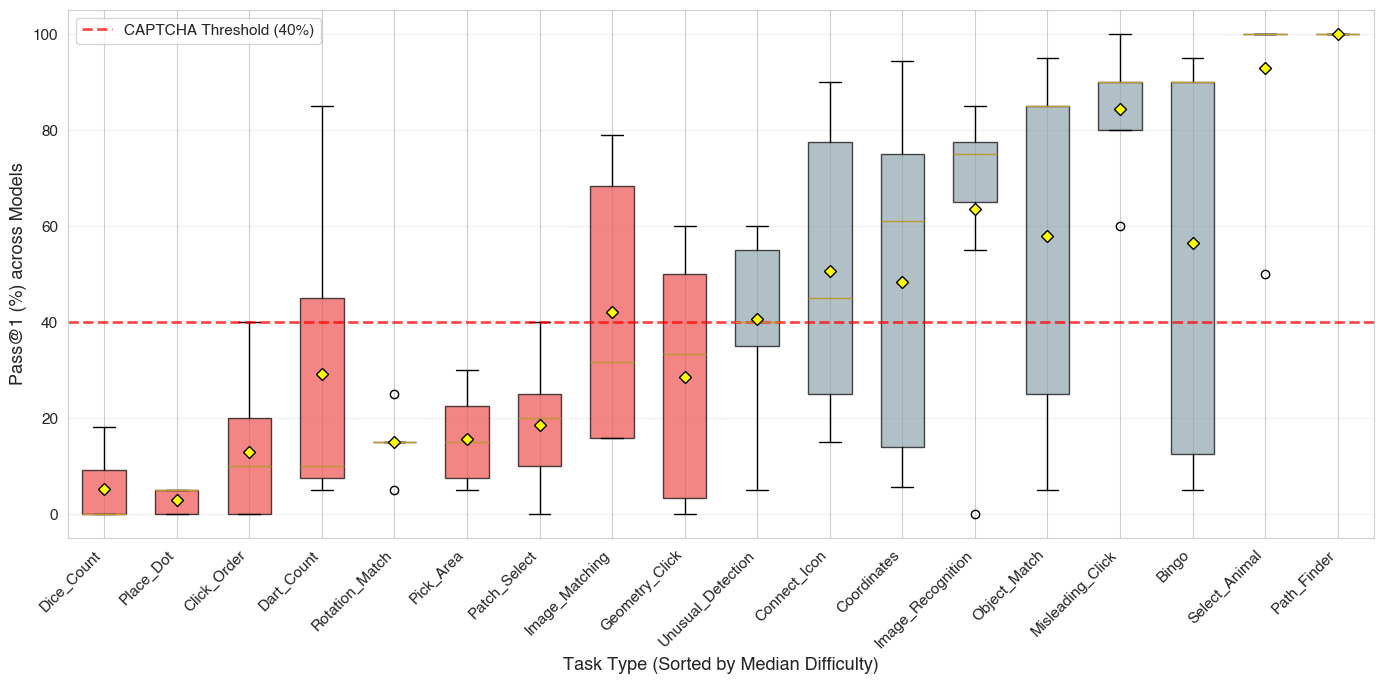

In [6]:
# Chart 4: Box Plot - Cross-Model Stability
FIGURE_SIZE_BOX = (14, 7)


SELECTED_EXPERIMENT = 'exp1'  # Options: 'exp1', 'exp2', 'exp3', 'exp4'

CHART4_SIZES = {
    'base': 12,
    'title': 14,
    'label': 13,
    'tick': 11,
    'legend': 11,
    'annotation': 11,  # 箱线图中位数/均值等文字（如果有）
}
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica'],
    'font.size': CHART4_SIZES['base'],
    'axes.titlesize': CHART4_SIZES['title'],
    'axes.labelsize': CHART4_SIZES['label'],
    'xtick.labelsize': CHART4_SIZES['tick'],
    'ytick.labelsize': CHART4_SIZES['tick'],
    'legend.fontsize': CHART4_SIZES['legend'],
})

if not viz.data.empty and SELECTED_EXPERIMENT in viz.data['experiment'].values:
    # Check if there are multiple models for comparison
    n_models = len(viz.data[viz.data['experiment'] == SELECTED_EXPERIMENT]['provider_model'].unique())
    if n_models >= 2:
        print(f"Generating cross-model stability box plot for {SELECTED_EXPERIMENT}...")
        fig = viz.plot_cross_model_stability(
            experiment=SELECTED_EXPERIMENT,
            figsize=FIGURE_SIZE_BOX,
            save_path=f"./figures/stability_{SELECTED_EXPERIMENT}.pdf"
        )
        if fig:
            ax = plt.gca()
            # ax.title.set_fontsize(CHART4_SIZES['title'])
            ax.xaxis.label.set_fontsize(CHART4_SIZES['label'])
            ax.yaxis.label.set_fontsize(CHART4_SIZES['label'])
            for tick in ax.get_xticklabels() + ax.get_yticklabels():
                tick.set_fontsize(CHART4_SIZES['tick'])
            for txt in ax.texts:
                txt.set_fontsize(CHART4_SIZES['annotation'])
            leg = ax.get_legend()
            if leg:
                leg.set_fontsize(CHART4_SIZES['legend'])
        plt.show()
    else:
        print(f"[WARNING] Only {n_models} model(s) found, need at least 2 for stability analysis")
else:
    print(f"[WARNING] {SELECTED_EXPERIMENT} data not available")


## CAPTCHA Recommendation Report
Generates a detailed analysis report for CAPTCHA task selection.

## Chart 6: Cost–Performance Frontier


Generating cost–performance frontier for ['exp1', 'exp2']...
[SAVED] Frontier saved: ./figures/cost_performance_frontier_openai_gpt-5.pdf


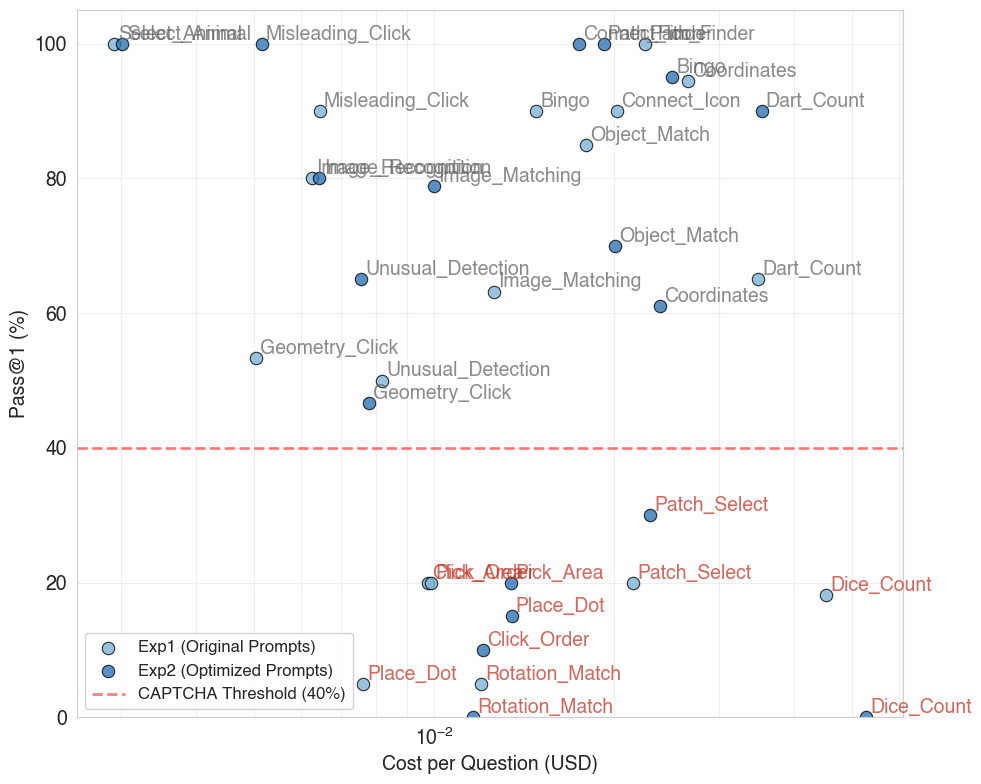

In [4]:
FIGURE_SIZE_FRONTIER = (10, 8)

import re as _re

def _model_slug(name):
    if not name:
        return 'all_models'
    return _re.sub(r'[^A-Za-z0-9._-]+', '_', str(name))

SELECTED_MODEL = "openai/gpt-5"  # Set to None to include all models
# Chart 6: Cost–Performance Frontier
# Uses cost_per_question (USD) vs Pass@1 (%) with multiple experiments overlaid
CHART6_SIZES = {
    'base': 12,
    'title': 14,
    'label': 14,
    'tick': 14,
    'legend': 12,
    'annotation': 14,  # 点旁文字
}
CHART6_STYLE = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica'],
    'font.size': CHART6_SIZES['base'],
    'axes.titlesize': CHART6_SIZES['title'],
    'axes.labelsize': CHART6_SIZES['label'],
    'xtick.labelsize': CHART6_SIZES['tick'],
    'ytick.labelsize': CHART6_SIZES['tick'],
    'legend.fontsize': CHART6_SIZES['legend'],
}
plt.rcParams.update(CHART6_STYLE)

EXPERIMENTS_TO_COMPARE = ['exp1', 'exp2']
if not viz.data.empty:
    available_exps = [exp for exp in EXPERIMENTS_TO_COMPARE if exp in viz.data['experiment'].values]
    if len(available_exps) >= 1:
        print(f"Generating cost–performance frontier for {available_exps}...")
        fig = viz.plot_cost_performance_frontier(
            experiments=available_exps,
            model_filter=SELECTED_MODEL,
            figsize=FIGURE_SIZE_FRONTIER,
            font_sizes=CHART6_SIZES,
            save_path=f"./figures/cost_performance_frontier_{_model_slug(SELECTED_MODEL)}.pdf"
        )
        plt.show()
    else:
        print('[WARNING] No valid experiments for frontier plot')
else:
    print('[WARNING] No data')

## Chart 7: Time–Performance Scatter


Generating time–performance scatter for ['exp1', 'exp2']...
[SAVED] Time–Performance saved: ./figures/time_performance_scatter_openai_gpt-5.pdf


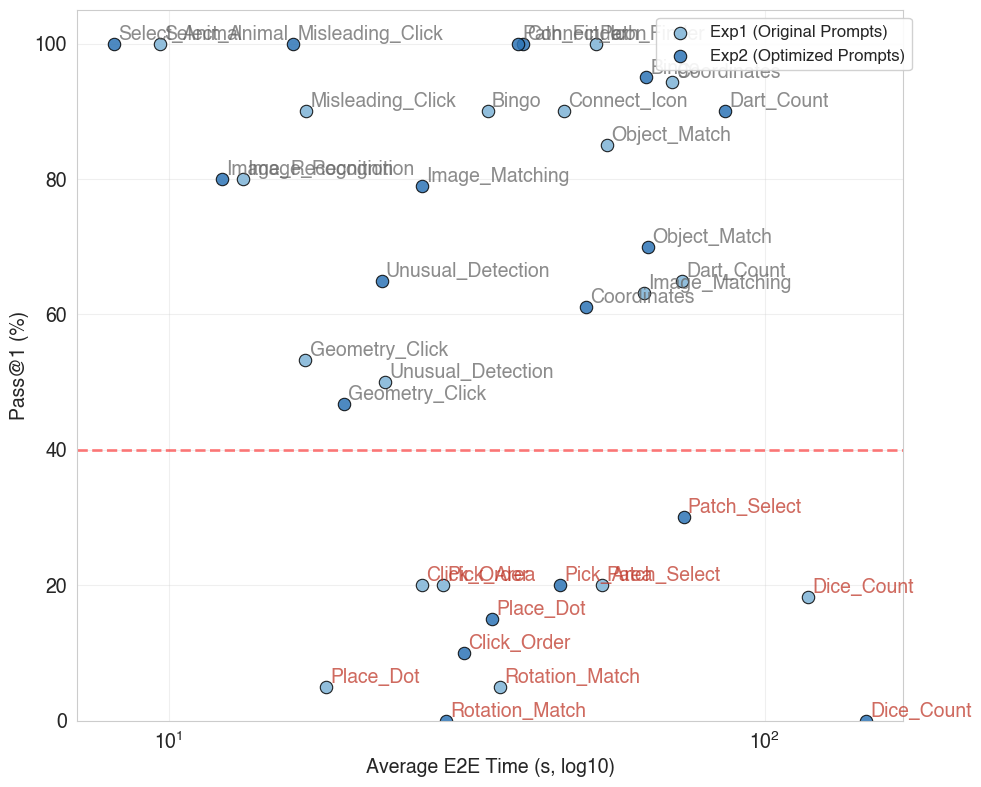

In [5]:
FIGURE_SIZE_TIME_PERF = (10, 8)

import re as _re

def _model_slug(name):
    if not name:
        return 'all_models'
    return _re.sub(r'[^A-Za-z0-9._-]+', '_', str(name))

SELECTED_MODEL = "openai/gpt-5"  # Set to None to include all models
# Chart 7: Time–Performance Scatter
# Uses avg_e2e_ms vs Pass@1 (%) with multiple experiments overlaid
CHART7_SIZES = {
    'base': 12,
    'title': 14,
    'label': 14,
    'tick': 14,
    'legend': 12,
    'annotation': 14,
}
CHART7_STYLE = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica'],
    'font.size': CHART7_SIZES['base'],
    'axes.titlesize': CHART7_SIZES['title'],
    'axes.labelsize': CHART7_SIZES['label'],
    'xtick.labelsize': CHART7_SIZES['tick'],
    'ytick.labelsize': CHART7_SIZES['tick'],
    'legend.fontsize': CHART7_SIZES['legend'],
}
plt.rcParams.update(CHART7_STYLE)

EXPERIMENTS_TO_COMPARE = ['exp1', 'exp2']
if not viz.data.empty:
    available_exps = [exp for exp in EXPERIMENTS_TO_COMPARE if exp in viz.data['experiment'].values]
    if len(available_exps) >= 1:
        print(f"Generating time–performance scatter for {available_exps}...")
        fig = viz.plot_time_performance_scatter(
            experiments=available_exps,
            model_filter=SELECTED_MODEL,
            figsize=FIGURE_SIZE_TIME_PERF,
            font_sizes=CHART7_SIZES,
            save_path=f"./figures/time_performance_scatter_{_model_slug(SELECTED_MODEL)}.pdf"
        )
        ax = plt.gca()
        # Use logarithmic scale and log tick formatter
        from matplotlib.ticker import LogLocator, LogFormatterMathtext
        ax.set_xscale('log')
        ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,)))
        ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=(2,3,4,5,6,7,8,9)))
        ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
        ax.set_xlabel('Average E2E Time (s, log10)', fontsize=CHART7_SIZES['label'])
        # Move legend to upper-right
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.02, 1),
                      fontsize=CHART7_SIZES['legend'], framealpha=0.9)
        plt.show()
    else:
        print('[WARNING] No valid experiments for time–performance plot')
else:
    print('[WARNING] No data')

## 综合分析：单次成功率 → 重试表现 → 成功成本
完整分析某个模型在 Exp2 下的：
1. Pass@1 → Success@3 映射
2. 单 session 重试（A3）vs 长期调用次数（1/p）
3. 成本–性能关系（cost_per_success）

## Chart 8：Pass@1 → Success@3 → 成功成本
完整分析脚本，用于论文图表生成

In [9]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# 图表样式配置 (Chart 8)
# ============================================================================
CHART8_SIZES = {
    'base': 12,              # 全局基准字号
    'title': 12,             # 标题字号
    'label': 14,             # 轴标签字号
    'tick': 14,              # 坐标刻度字号
    'legend': 14,            # 图例字号
    'annotation_hard': 14,   # 困难任务标注字号
    'annotation_normal': 14, # 普通任务标注字号
    'bar_value': 13,         # 柱子数值标签字号
}
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica'],
    'font.size': CHART8_SIZES['base'],
    'axes.titlesize': CHART8_SIZES['title'],
    'axes.labelsize': CHART8_SIZES['label'],
    'xtick.labelsize': CHART8_SIZES['tick'],
    'ytick.labelsize': CHART8_SIZES['tick'],
    'legend.fontsize': CHART8_SIZES['legend'],
})

# 字体调节入口（供下个 cell 使用）
LABEL_FONTSIZE_HARD = CHART8_SIZES['annotation_hard']
LABEL_FONTSIZE_NORMAL = CHART8_SIZES['annotation_normal']
BAR_VALUE_FONTSIZE = CHART8_SIZES['bar_value']

分析模型: GPT-5 (Medium) (openai/gpt-5)
[1/6] 读取预测数据...
  ✓ 加载了 18 个任务类型
[2/6] 读取成本数据...
  ✓ 加载了 18 个任务的成本数据
  ✓ 平均每次调用成本: $0.017072
[3/6] 计算统计量...
  ✓ Pass@1 范围: 0.000 - 1.000
  ✓ Success@3 范围: 0.000 - 1.000
  ✓ 困难任务数量: 6 / 18
[4/6] 绘制图 1a: Pass@1 → Success@3 散点图...
  ✓ 已保存: figures/exp3_mapping_pass_to_success_openai_gpt-5.pdf
[5/6] 绘制图 1b: 期望调用次数柱状图...
  ✓ 已保存: figures/exp3_mapping_expected_calls_openai_gpt-5.pdf
[6/6] 绘制图 2: 成本–性能散点图...
  ✓ 已保存: figures/cost_success_openai_gpt-5.pdf
统计摘要
【最困难的 5 个任务】(最低 Pass@1):
  Dice_Count            Pass@1:   0.0%  Success@3:   0.0%  Calls:    inf
  Rotation_Match        Pass@1:   0.0%  Success@3:   0.0%  Calls:    inf
  Click_Order           Pass@1:  10.0%  Success@3:  27.1%  Calls:   10.0
  Place_Dot             Pass@1:  15.0%  Success@3:  38.6%  Calls:    6.7
  Pick_Area             Pass@1:  20.0%  Success@3:  48.8%  Calls:    5.0
【最简单的 5 个任务】(最高 Pass@1):
  Connect_Icon          Pass@1: 100.0%  Success@3: 100.0%  Calls:    1.0
  Misleading_Click 

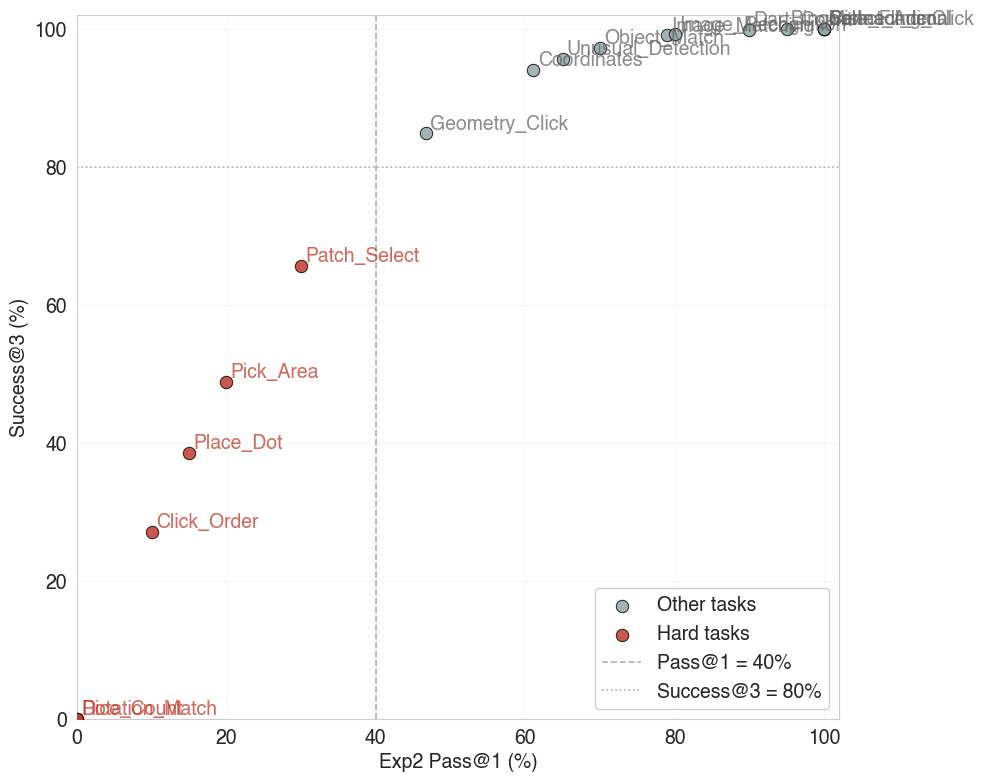

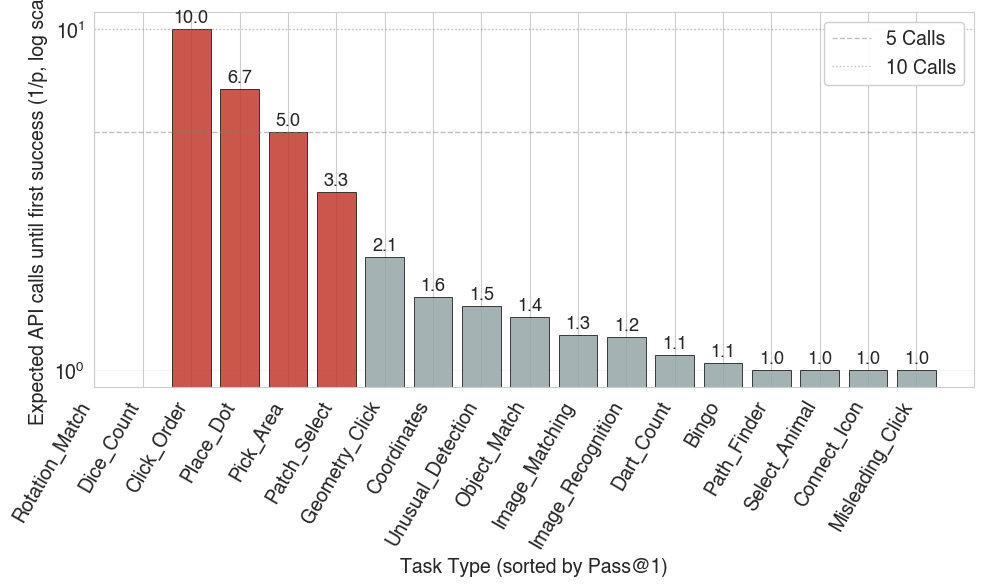

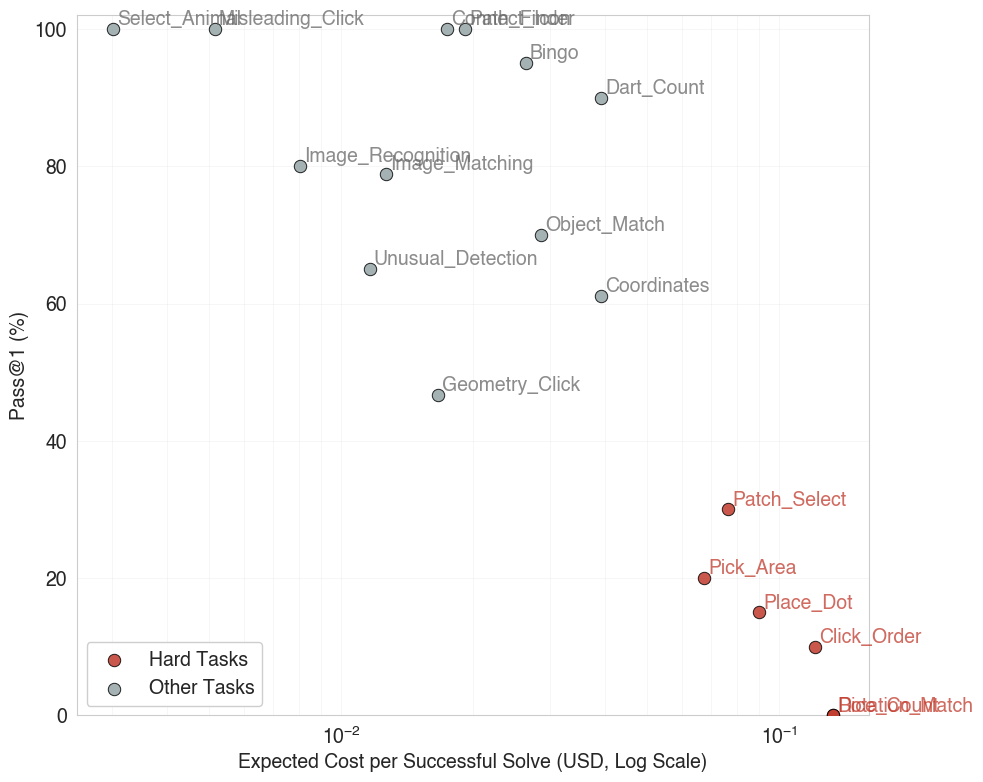

In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
完整分析脚本：单次成功率 → 有限重试 → 成功成本
用于论文图表生成
"""



# ============================================================================
# 配置参数（可根据需要修改）
# ============================================================================

# 输入文件路径
PREDICTION_CSV = './exp2_to_exp3_predictions_nb.csv'
RESULTS_DIR = './results'  # 成本数据所在的目录

# 选定的模型
TARGET_MODEL = 'openai/gpt-5'  # 修改此处切换模型
MODEL_DISPLAY_NAME = 'GPT-5 (Medium)'   # 图表中显示的名称

# 输出目录和文件名前缀
OUTPUT_DIR = './figures'

# 候选困难任务列表（用于红色高亮）
HARD_TASKS = [
    'Patch_Select', 'Rotation_Match', 'Click_Order',
    'Pick_Area', 'Place_Dot', 'Dice_Count'
]

# 阈值线参考值
THRESHOLD_PASS1 = 40  # Pass@1 阈值 (%)
THRESHOLD_SUCCESS3 = 80  # Success@3 阈值 (%)
THRESHOLD_CALLS_5 = 5  # 5 calls 参考线
THRESHOLD_CALLS_10 = 10  # 10 calls 参考线

# 人工 CAPTCHA 参考成本（USD）
HUMAN_CAPTCHA_COST = 0.01

# 字体调节入口（Chart 8）
LABEL_FONTSIZE_HARD = CHART8_SIZES['annotation_hard']
LABEL_FONTSIZE_NORMAL = CHART8_SIZES['annotation_normal']
BAR_VALUE_FONTSIZE = CHART8_SIZES['bar_value']

# ============================================================================
# 辅助函数：从 results.csv 读取成本数据
# ============================================================================

def load_cost_data(results_dir, provider_model, experiment='exp2'):
    """
    从 results/{exp}/{provider}/{model}/results.csv 读取成本数据

    Parameters:
    -----------
    results_dir : str
        results 目录路径
    provider_model : str
        格式为 'provider/model'，例如 'openai/gpt-5.1_medium'
    experiment : str
        实验名称，默认 'exp2'

    Returns:
    --------
    pd.DataFrame
        包含 task_type 和 cost_per_question 的数据框
    """
    provider, model = provider_model.split('/')
    results_path = Path(results_dir) / experiment / provider / model / 'results.csv'
    if not results_path.exists():
        print(f"  ⚠ 成本文件不存在: {results_path}")
        return pd.DataFrame()
    df = pd.read_csv(results_path)
    df = df.rename(columns={'type': 'task_type'})
    df = df[['task_type', 'cost_per_question']].copy()
    return df

# ============================================================================
# 数据加载与处理
# ============================================================================

print("=" * 80)
print(f"分析模型: {MODEL_DISPLAY_NAME} ({TARGET_MODEL})")
print("=" * 80)

# 1. 读取预测数据
print("[1/6] 读取预测数据...")
df_pred = pd.read_csv(PREDICTION_CSV)
df = df_pred[df_pred['provider_model'] == TARGET_MODEL].copy()
if df.empty:
    raise ValueError(f"未找到模型 {TARGET_MODEL} 的数据")
print(f"  ✓ 加载了 {len(df)} 个任务类型")

# 2. 读取成本数据
print("[2/6] 读取成本数据...")
df_cost = load_cost_data(RESULTS_DIR, TARGET_MODEL, experiment='exp2')
if not df_cost.empty:
    print(f"  ✓ 加载了 {len(df_cost)} 个任务的成本数据")
    df = df.merge(df_cost, on='task_type', how='left')
    avg_cost = df['cost_per_question'].mean()
    print(f"  ✓ 平均每次调用成本: ${avg_cost:.6f}")
else:
    print(f"  ⚠ 未找到成本数据")
    df['cost_per_question'] = np.nan

# 3. 计算派生统计量
print("[3/6] 计算统计量...")
df['p'] = df['p_hat'].astype(float)
df['success3'] = 1 - (1 - df['p']) ** 3
df['calls_until_success'] = np.where(df['p'] > 0, 1.0 / df['p'], np.inf)
if 'cost_per_question' in df.columns:
    df['cost_per_success'] = df['calls_until_success'] * df['cost_per_question']
else:
    df['cost_per_success'] = np.nan
df['is_hard'] = df['task_type'].isin(HARD_TASKS)
print(f"  ✓ Pass@1 范围: {df['p'].min():.3f} - {df['p'].max():.3f}")
print(f"  ✓ Success@3 范围: {df['success3'].min():.3f} - {df['success3'].max():.3f}")
print(f"  ✓ 困难任务数量: {df['is_hard'].sum()} / {len(df)}")

# ============================================================================
# 图 1a：Pass@1 → Success@3 散点图
# ============================================================================

print("[4/6] 绘制图 1a: Pass@1 → Success@3 散点图...")

fig1a, ax_left = plt.subplots(figsize=(10, 8))

hard_df = df[df['is_hard']]
easy_df = df[~df['is_hard']]
ax_left.scatter(easy_df['p'] * 100, easy_df['success3'] * 100,
               c='#95a5a6', s=80, edgecolors='k', linewidths=0.7,
               alpha=0.85, label='Other tasks', zorder=2)
ax_left.scatter(hard_df['p'] * 100, hard_df['success3'] * 100,
               c='#c0392b', s=80, edgecolors='k', linewidths=0.7,
               alpha=0.85, label='Hard tasks', zorder=3)
for _, row in df.iterrows():
    color = '#c0392b' if row['is_hard'] else '#666666'
    fontsize = LABEL_FONTSIZE_HARD if row['is_hard'] else LABEL_FONTSIZE_NORMAL
    ax_left.annotate(row['task_type'],
        xy=(row['p'] * 100, row['success3'] * 100),
        xytext=(3, 3), textcoords='offset points',
        fontsize=fontsize, alpha=0.75, color=color, zorder=4)
ax_left.axvline(THRESHOLD_PASS1, color='gray', linestyle='--',
               linewidth=1.2, alpha=0.6, label=f'Pass@1 = {THRESHOLD_PASS1}%')
ax_left.axhline(THRESHOLD_SUCCESS3, color='gray', linestyle=':',
               linewidth=1.2, alpha=0.6, label=f'Success@3 = {THRESHOLD_SUCCESS3}%')
ax_left.set_xlim(0, 102)
ax_left.set_ylim(0, 102)
ax_left.set_xlabel('Exp2 Pass@1 (%)')
ax_left.set_ylabel('Success@3 (%)')
# ax_left.set_title(f'Mapping Exp2 Pass@1 to Success@3\nModel: {MODEL_DISPLAY_NAME}')
ax_left.legend(loc='lower right', framealpha=0.95)
ax_left.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)
fig1a.tight_layout()
model_slug = TARGET_MODEL.replace('/', '_')
output_path_1a = Path(OUTPUT_DIR) / f"exp3_mapping_pass_to_success_{model_slug}.pdf"
output_path_1a.parent.mkdir(parents=True, exist_ok=True)
fig1a.savefig(output_path_1a, format='pdf', bbox_inches='tight', dpi=300)
print(f"  ✓ 已保存: {output_path_1a}")

# ============================================================================
# 图 1b：期望调用次数 (1/p) 柱状图
# ============================================================================

print("[5/6] 绘制图 1b: 期望调用次数柱状图...")

fig1b, ax_right = plt.subplots(figsize=(10, 6))
df_sorted = df.sort_values('p', ascending=True).reset_index(drop=True)
x_pos = np.arange(len(df_sorted))
colors_bar = ['#c0392b' if is_hard else '#95a5a6' for is_hard in df_sorted['is_hard']]
bars = ax_right.bar(x_pos, df_sorted['calls_until_success'],
                   color=colors_bar, edgecolor='k', linewidth=0.6,
                   alpha=0.85, width=0.8)
ax_right.axhline(THRESHOLD_CALLS_5, color='gray', linestyle='--',
                linewidth=1.0, alpha=0.5, label='5 Calls')
ax_right.axhline(THRESHOLD_CALLS_10, color='gray', linestyle=':',
                linewidth=1.0, alpha=0.5, label='10 Calls')
ax_right.set_xticks(x_pos)
ax_right.set_xticklabels(df_sorted['task_type'], rotation=60, ha='right')
ax_right.set_xlabel('Task Type (sorted by Pass@1)')
ax_right.set_ylabel('Expected API Calls until First Success (1/p)')
# ax_right.set_title(f'Expected Calls until First Success\nModel: {MODEL_DISPLAY_NAME}')
max_calls = df_sorted['calls_until_success'].max()
if max_calls > 50:
    ax_right.set_yscale('log')
    ax_right.set_ylabel('Expected API calls until first success (1/p, log scale)')
for x_idx, row in enumerate(df_sorted.itertuples(index=False)):
    val = row.calls_until_success
    if np.isfinite(val):
        offset = val * 1.02 if val > 0 else val + 0.1
        ax_right.text(x_idx, offset, f"{val:.1f}",
                      ha='center', va='bottom', fontsize=BAR_VALUE_FONTSIZE)
ax_right.legend(loc='upper right', framealpha=0.95)
ax_right.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, axis='y')
fig1b.tight_layout()
output_path_1b = Path(OUTPUT_DIR) / f"exp3_mapping_expected_calls_{model_slug}.pdf"
fig1b.savefig(output_path_1b, format='pdf', bbox_inches='tight', dpi=300)
print(f"  ✓ 已保存: {output_path_1b}")

# ============================================================================
# 图 2：成本–性能散点图
# ============================================================================

print("[6/6] 绘制图 2: 成本–性能散点图...")

if not df['cost_per_success'].isna().all():
    fig2, ax = plt.subplots(figsize=(10, 8))
    df_cost_valid = df.dropna(subset=['cost_per_success']).copy()
    finite_max = df_cost_valid['cost_per_success'].replace([np.inf, -np.inf], np.nan).max()
    if pd.notna(finite_max):
        df_cost_valid.loc[~np.isfinite(df_cost_valid['cost_per_success']), 'cost_per_success'] = finite_max * 1.1
    else:
        df_cost_valid = df_cost_valid[np.isfinite(df_cost_valid['cost_per_success'])]
    hard_df = df_cost_valid[df_cost_valid['is_hard']]
    easy_df = df_cost_valid[~df_cost_valid['is_hard']]
    ax.scatter(hard_df['cost_per_success'], hard_df['p'] * 100,
              c='#c0392b', s=80, edgecolors='k', linewidths=0.7,
              alpha=0.85, label='Hard Tasks', zorder=3)
    ax.scatter(easy_df['cost_per_success'], easy_df['p'] * 100,
              c='#95a5a6', s=80, edgecolors='k', linewidths=0.7,
              alpha=0.85, label='Other Tasks', zorder=2)
    for _, row in df_cost_valid.iterrows():
        color = '#c0392b' if row['is_hard'] else '#666666'
        fontsize = LABEL_FONTSIZE_HARD if row['is_hard'] else LABEL_FONTSIZE_NORMAL
        ax.annotate(row['task_type'],
            xy=(row['cost_per_success'], row['p'] * 100),
            xytext=(3, 3), textcoords='offset points',
            fontsize=fontsize, alpha=0.75, color=color, zorder=4)
    ax.set_xscale('log')
    ax.set_xlabel('Expected Cost per Successful Solve (USD, Log Scale)')
    ax.set_ylabel('Pass@1 (%)')
    # ax.set_title(f'Expected Cost per Successful Solve vs. Pass@1\nModel: {MODEL_DISPLAY_NAME}')
    ax.legend(loc='best', framealpha=0.95)
    ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, which='both')
    ax.set_ylim(0, 102)
    fig2.tight_layout()
    output_path_2 = Path(OUTPUT_DIR) / f"cost_success_{model_slug}.pdf"
    fig2.savefig(output_path_2, format='pdf', bbox_inches='tight', dpi=300)
    print(f"  ✓ 已保存: {output_path_2}")
else:
    print("  ⚠ 无成本数据，跳过图 2")

# ============================================================================
# 统计摘要
# ============================================================================

print("" + "=" * 80)
print("统计摘要")
print("=" * 80)

print("【最困难的 5 个任务】(最低 Pass@1):")
hardest = df.nsmallest(5, 'p')[['task_type', 'p', 'success3', 'calls_until_success']]
for idx, row in hardest.iterrows():
    print(f"  {row['task_type']:20s}  Pass@1: {row['p']*100:5.1f}%  "
          f"Success@3: {row['success3']*100:5.1f}%  Calls: {row['calls_until_success']:6.1f}")

print("【最简单的 5 个任务】(最高 Pass@1):")
easiest = df.nlargest(5, 'p')[['task_type', 'p', 'success3', 'calls_until_success']]
for idx, row in easiest.iterrows():
    print(f"  {row['task_type']:20s}  Pass@1: {row['p']*100:5.1f}%  "
          f"Success@3: {row['success3']*100:5.1f}%  Calls: {row['calls_until_success']:6.1f}")

if not df['cost_per_success'].isna().all():
    print("【成本最高的 5 个任务】:")
    expensive = df.nlargest(5, 'cost_per_success')[['task_type', 'p', 'cost_per_success']]
    for idx, row in expensive.iterrows():
        print(f"  {row['task_type']:20s}  Pass@1: {row['p']*100:5.1f}%  "
              f"Cost: ${row['cost_per_success']:.6f}")

print("" + "=" * 80)
print("✓ 分析完成！")
print("=" * 80)

plt.show()